# Meteorology Forecasting 

This notebook documents a complete time-series forecasting pipeline that **predicts meteorological variables 24 hours ahead** across multiple Portuguese cities. It covers:

1. **Pipeline Overview** — how the five scripts connect end-to-end  
2. **Preprocessing** (`01_preprocess.py`) — cleaning, cyclical time & wind encoding  
3. **Feature Engineering** (`02_feature_engineering.py`) — lag features, rolling windows, interaction terms  
4. **Model Design** (`models_04.py`) — LightGBM for temperature, XGBoost Tweedie for rain  
5. **Walk-Forward Validation** (`03_walk_forward.py`) — expanding-window temporal evaluation  
6. **Evaluation & Results** (`05_evaluate.py`) — metrics, plots, competition score  

---


## 1. Pipeline Overview

The full pipeline is orchestrated by `run_pipeline.py`, which calls four scripts in sequence:

```
raw CSV
   │
   ▼
01_preprocess.py          →  data/processed.parquet
   │
   ▼
02_feature_engineering.py →  data/features.parquet
   │
   ▼
03_walk_forward.py        →  results/walk_forward_results.csv
   │
   ▼
05_evaluate.py            →  results/plots/  +  results/main_metrics_report.txt
```

Each step reads the output of the previous one as a Parquet or CSV file. The modular design means any step can be re-run independently — for example, changing only the model in `models_04.py` and re-running `03_walk_forward.py` and `05_evaluate.py` without reprocessing the raw data.


```bash
python run_pipeline.py
```


---
## 2. Preprocessing (`01_preprocess.py`)

The preprocessing script loads the raw meteorology CSV and applies four transformations before saving a clean Parquet file.

### 2.1 Cyclical Time Encoding

Hours and months are periodic: hour 23 is one step away from hour 0, and December is one step away from January. A linear integer encoding (e.g. hour=23 vs hour=0) would incorrectly represent these as maximally distant.

**Cyclical encoding** projects each value onto a unit circle using sine and cosine:

```
hour_sin = sin(2π × hour / 24)
hour_cos = cos(2π × hour / 24)
```

This way, the model sees hour 23 and hour 0 as close together numerically, just as they are in real time.

| Feature | Period | Encoded as |
|---|---|---|
| `hour` | 24 h | `hour_sin`, `hour_cos` |
| `month` | 12 months | `month_sin`, `month_cos` |
| `day_of_year` | kept as integer | — |

### 2.2 Cyclical Wind Direction Encoding

Wind direction is also circular (359° ≈ 1°). Raw degrees would create a false discontinuity at 0°/360°. The same sin/cos trick is applied using `np.deg2rad()`:

```python
wind_dir_10m_sin  = sin(rad(wind_direction_10m))
wind_dir_10m_cos  = cos(rad(wind_direction_10m))
```

The raw degree columns are then **dropped** — all the directional information is preserved in the two encoded columns.


In [1]:
# 01_preprocess.py — Preprocessing pipeline

import numpy as np
import pandas as pd

def preprocess(raw_csv_path: str, out_parquet_path: str):
    df = pd.read_csv(raw_csv_path)

    # ── Step 1: Clean column / value whitespace ───────────────────────────
    df.columns    = df.columns.str.strip()
    df["location"] = df["location"].str.strip()

    # ── Step 2: Parse datetime and sort by [location, time] ───────────────
    df["time"] = pd.to_datetime(df["time"].str.strip())
    df = df.sort_values(["location", "time"]).reset_index(drop=True)

    # ── Step 3: Cyclical time encoding ────────────────────────────────────
    hour      = df["time"].dt.hour
    month     = df["time"].dt.month

    df["hour_sin"]    = np.sin(2 * np.pi * hour  / 24)
    df["hour_cos"]    = np.cos(2 * np.pi * hour  / 24)
    df["month_sin"]   = np.sin(2 * np.pi * month / 12)
    df["month_cos"]   = np.cos(2 * np.pi * month / 12)
    df["day_of_year"] = df["time"].dt.day_of_year

    # ── Step 4: Cyclical wind direction encoding ──────────────────────────
    for level in ["10m", "100m"]:
        col = f"wind_direction_{level}"
        df[f"wind_dir_{level}_sin"] = np.sin(np.deg2rad(df[col]))
        df[f"wind_dir_{level}_cos"] = np.cos(np.deg2rad(df[col]))
    df = df.drop(columns=["wind_direction_10m", "wind_direction_100m"])

    # ── Step 5: Save ──────────────────────────────────────────────────────
    df.to_parquet(out_parquet_path, index=False)
    print(f"Saved → {out_parquet_path}  |  Shape: {df.shape}")


---
## 3. Feature Engineering (`02_feature_engineering.py`)

Four classes of features are built, **all computed per-location group** to prevent information from bleeding across city boundaries.

### 3.1 Target Variable: 24-Hour Ahead Forecast

The target for each row at time `t` is the actual observed value at time `t + 24h`:

```python
grp["target_temperature_2m"] = grp["temperature_2m"].shift(-24)
grp["target_rain"]           = grp["rain"].shift(-24)
```

This means the model is always **predicting tomorrow** — given everything we know up to right now, what will the weather be in 24 hours?

> The last 24 rows of each location lose their target (they'd need data from the future that doesn't exist). These rows are dropped.

### 3.2 Lag Features

Lag features tell the model what the weather was like in the past. Multiple lookback windows are used:

| Shift | Meaning (relative to prediction horizon) |
|---|---|
| `lag_0h` | Current value at `t` — 24h before the target |
| `lag_1h` | 1 hour ago — 25h before the target |
| `lag_24h` | Yesterday same hour — captures the diurnal cycle |
| `lag_72h` | 3 days ago — captures multi-day weather patterns |

Lags are created for: `temperature_2m`, `rain`, `relative_humidity_2m`, `cloud_cover`, `wind_speed_10m`, `pressure_msl`.

### 3.3 Rolling Mean Features

Rolling means smooth out noise and capture trends, with window sizes matched to the variable's timescale:

| Variable | Window | Rationale |
|---|---|---|
| `cloud_cover`, `relative_humidity_2m` | 3h | Fast-changing — short memory |
| `temperature_2m` | 6h | Moderate inertia |
| `pressure_msl` | 24h | Slow-changing — synoptic scale |
| `rain` | 72h | Smooths the heavy-zero distribution |

> `.rolling(n).mean()` at position `i` uses only rows `[i-n+1 … i]` — it never touches future data, so there is no leakage.

### 3.4 Interaction Features

Three domain-informed interactions are computed:

| Feature | Formula | Meaning |
|---|---|---|
| `temp_dew_spread` | `temperature_2m − dew_point_2m` | Dew point depression; near-zero → fog/rain risk |
| `pressure_diff` | `pressure_msl − surface_pressure` | Altitude-corrected pressure anomaly |
| `wind_speed_diff` | `wind_speed_100m − wind_speed_10m` | Wind shear — increases with atmospheric instability |


In [2]:
# 02_feature_engineering.py — Feature engineering pipeline

import numpy as np
import pandas as pd

RAW_TO_TARGET = {
    "temperature_2m": "target_temperature_2m",
    "rain":           "target_rain",
}

LAG_COLS   = ["temperature_2m", "rain", "relative_humidity_2m",
              "cloud_cover", "wind_speed_10m", "pressure_msl"]
LAG_SHIFTS = [0, 1, 24, 72]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    groups = []

    for loc, grp in df.groupby("location", sort=False):
        grp = grp.copy().sort_values("time").reset_index(drop=True)

        # 1. Target columns (24h-ahead forecast)
        for raw_col, tgt_col in RAW_TO_TARGET.items():
            grp[tgt_col] = grp[raw_col].shift(-24)

        # 2. Lag features
        for col in LAG_COLS:
            for s in LAG_SHIFTS:
                grp[f"{col}_lag_{s}h"] = grp[col].shift(s)

        # 3. Rolling mean features (no leakage — rolling only over past data)
        grp["cloud_cover_roll3h"]         = grp["cloud_cover"].rolling(3,  min_periods=1).mean()
        grp["relative_humidity_2m_roll3h"]= grp["relative_humidity_2m"].rolling(3, min_periods=1).mean()
        grp["temperature_2m_roll6h"]      = grp["temperature_2m"].rolling(6,  min_periods=1).mean()
        grp["pressure_msl_roll24h"]       = grp["pressure_msl"].rolling(24, min_periods=1).mean()
        grp["rain_roll72h"]               = grp["rain"].rolling(72, min_periods=1).mean()

        # 4. Interaction features
        grp["temp_dew_spread"] = grp["temperature_2m"] - grp["dew_point_2m"]
        grp["pressure_diff"]   = grp["pressure_msl"]   - grp["surface_pressure"]
        grp["wind_speed_diff"] = grp["wind_speed_100m"]- grp["wind_speed_10m"]

        groups.append(grp)

    result = pd.concat(groups, ignore_index=True)

    # 5. Encode location as integer
    result["location_id"] = result["location"].astype("category").cat.codes

    # 6. Drop rows where any target is NaN
    result = result.dropna(subset=list(RAW_TO_TARGET.values())).reset_index(drop=True)
    return result


---
## 4. Model Design (`models_04.py`)

A different model is used for each target variable, chosen based on the statistical properties of the output distribution.

### 4.1 Temperature → LightGBM Regressor

Temperature has a **smooth, continuous, bell-shaped distribution** with strong diurnal and seasonal cycles. LightGBM is well-suited because:
- `num_leaves=63` gives it enough depth to capture non-linear interactions (e.g. cloud × humidity × season)
- Subsample + column sampling reduce variance
- Light regularisation (`reg_alpha=0.05`, `reg_lambda=0.1`) prevents overfitting to specific weather events

```python
lgb.LGBMRegressor(
    n_estimators=600, learning_rate=0.05,
    num_leaves=63,    subsample=0.8,
    colsample_bytree=0.8
)
```

### 4.2 Rain → XGBoost Tweedie Regressor

Rain has a **zero-inflated, right-skewed distribution** — roughly 82% of hourly readings are exactly 0 mm, and the rest span from a trace to 22.8 mm. Standard regression fails here.

**Tweedie regression** is purpose-built for this:
- `objective="reg:tweedie"` with `tweedie_variance_power=1.5` sits between Poisson (1.0) and Gamma (2.0), matching the compound Poisson-Gamma nature of rainfall
- Predictions are always ≥ 0 by construction
- Avoids the high false-positive rate of two-stage classifiers (a LogisticRegression + HistGBM two-stage approach was tested and discarded)

```python
xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    objective="reg:tweedie", tweedie_variance_power=1.5
)
```

> After prediction, values < 0.1 mm are clipped to 0 as a practical "trace rain" threshold.


In [3]:
# models_04.py — Model factory

import lightgbm as lgb
import xgboost as xgb

TARGETS = ["target_temperature_2m", "target_rain"]

TARGET_SHORT = {
    "target_temperature_2m": "Temperature (C)",
    "target_rain":           "Rain (mm)",
}


def get_model(target: str):
    if target == "target_temperature_2m":
        return lgb.LGBMRegressor(
            n_estimators=600, learning_rate=0.05, num_leaves=63,
            max_depth=-1, min_child_samples=20,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.05, reg_lambda=0.1,
            random_state=42, n_jobs=-1, verbose=-1,
        )

    elif target == "target_rain":
        # Tweedie: native zero-heavy right-skewed distribution support
        # power=1.5 → compound Poisson-Gamma, matches rainfall physics
        return xgb.XGBRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            objective="reg:tweedie", tweedie_variance_power=1.5,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=42, n_jobs=-1, verbosity=0,
        )
    else:
        raise ValueError(f"Unknown target: {target}")


---
## 5. Walk-Forward Validation (`03_walk_forward.py`)

### Why Walk-Forward?

Standard cross-validation randomly shuffles rows into train/test folds. For time series, this causes **temporal leakage** — future data enters the training set. Walk-forward validation respects the time ordering:

```
Step 0: Train [0 … 2160h]     → Test [2160 … 2328h]  (week 1)
Step 1: Train [0 … 2328h]     → Test [2328 … 2496h]  (week 2)
Step 2: Train [0 … 2496h]     → Test [2496 … 2664h]  (week 3)
...
```

Each step **expands** the training window by one week (168 hours × number of locations). This simulates a real deployment scenario: the model has access to all historical data up to the current moment, and is evaluated on the next unknown week.

### Configuration

| Parameter | Value | Meaning |
|---|---|---|
| Initial training window | 3 months (~2,160 h/location) | Minimal history needed |
| Step size | 1 week (168 h × n_locs) | Evaluation granularity |
| Total steps | 40 | ~10 months of weekly evaluation |
| Locations | Multiple Portuguese cities | Each location treated as independent time series |

> Row counts are always multiplied by `n_locs` because each timestamp produces one row per location. The dataset has 118,800 rows across all steps and locations.


In [4]:
# 03_walk_forward.py — Expanding-window walk-forward validation (abridged)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

INITIAL_TRAIN_HOURS = 3 * 30 * 24  # ~2,160 h per location
STEP_SIZE_HOURS     = 7 * 24       # 168 h = 1 week

NON_FEATURE_COLS = {"target_temperature_2m", "target_rain", "time", "location"}


def walk_forward(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]

    n_locs             = df["location"].nunique()
    initial_train_rows = INITIAL_TRAIN_HOURS * n_locs
    step_size_rows     = STEP_SIZE_HOURS     * n_locs

    step_records, pred_records = [], []
    train_end = initial_train_rows
    step_idx  = 0

    while train_end < len(df):
        train_df = df.iloc[:train_end].dropna(subset=TARGETS)
        test_df  = df.iloc[train_end: train_end + step_size_rows].dropna(subset=TARGETS)

        if len(test_df) == 0:
            train_end += step_size_rows; continue

        X_train = train_df[feature_cols]
        X_test  = test_df[feature_cols]

        for target in TARGETS:
            model = get_model(target)
            model.fit(X_train, train_df[target])
            preds = model.predict(X_test)

            if target == "target_rain":
                preds = np.clip(preds, 0, None)
                preds[preds < 0.1] = 0.0

            mae = mean_absolute_error(test_df[target], preds)
            step_records.append({"step": step_idx, "target": target, "mae": mae,
                                  "train_size": len(train_df)})

        train_end += step_size_rows
        step_idx  += 1

    return pd.DataFrame(step_records)


---
## 6. Evaluation & Results (`05_evaluate.py`)

### 6.1 Summary Metrics

The evaluation was run over **118,800 rows** across **40 walk-forward steps** (steps 0–39).

| Target | MAE | RMSE | R² | Pearson r | Bias |
|---|---|---|---|---|---|
| Temperature 2m (°C) | **2.024** | 2.598 | 0.879 | 0.938 | +0.209 |
| Rain (mm) | **0.165** | 0.652 | 0.015 | 0.231 | −0.127 |

**Competition score formula:**
```
Score = (2.5 / (1 + MAE_global)) × (N_targets / 17) × 100
```
With global MAE = 1.095 (average of 2.024 and 0.165) and 2 active targets:
```
Score (2 targets)  = (2.5 / 1.095) × (2/17) × 100 = 14.04
```


### 6.2 Temperature Forecast — Actual vs Predicted

The temperature model tracks the actual signal closely throughout the full evaluation period (June → March). The diurnal oscillation (daily peaks and troughs) and the seasonal cooling trend through autumn and winter are both well-captured.

- **MAE = 2.02°C** — roughly ±2°C average error on a 24-hour ahead forecast
- **R² = 0.879** — the model explains ~88% of the total variance in temperature
- **Bias = +0.209°C** — a slight systematic overestimation; the model predicts warmer than reality on average
- **Pearson r = 0.938** — very high linear correlation between predictions and actuals


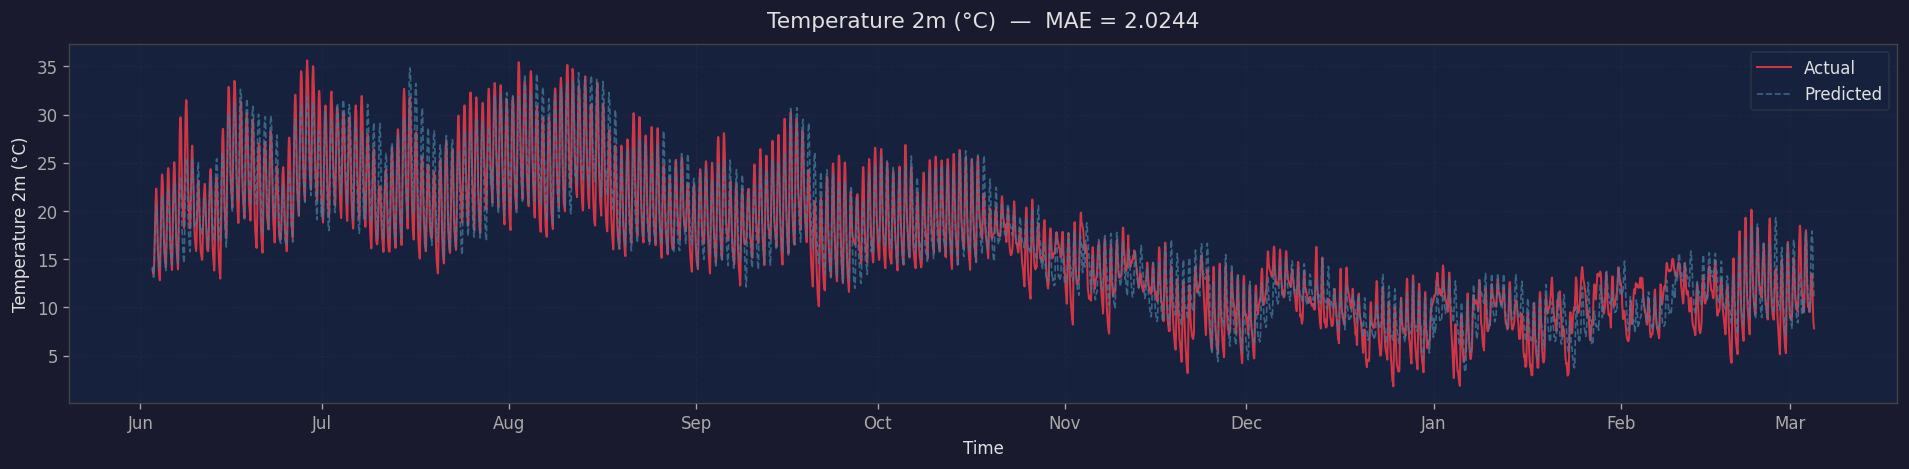

In [5]:
from pathlib import Path
from IPython.display import Image, display

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

img = _plots_dir() / 'target_temperature_2m_actual_vs_pred.png'
display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.3 Rain Forecast — Actual vs Predicted

Rain prediction is substantially harder due to its **spiky, zero-dominated distribution**. ~82% of hourly observations are exactly 0 mm, and rain events are sudden and localised.

- **MAE = 0.165 mm** — low absolute error, but partly because correctly predicting zero-rain hours is easy
- **R² = 0.015** — very low; the model captures almost none of the variance in extreme rain events
- **Bias = −0.127 mm** — systematic **underestimation**: the model is too conservative, especially during heavy rain
- **Pearson r = 0.231** — weak correlation; the model detects when rain occurs but misses the magnitude of peaks

From the plot the predicted line (cyan/dashed) appears nearly flat against the spiky actual values. This is a known challenge: the Tweedie model correctly identifies many dry hours and picks up moderate events, but the extreme spikes (up to 22.8 mm actual vs 3.2 mm max predicted) are severely underestimated.


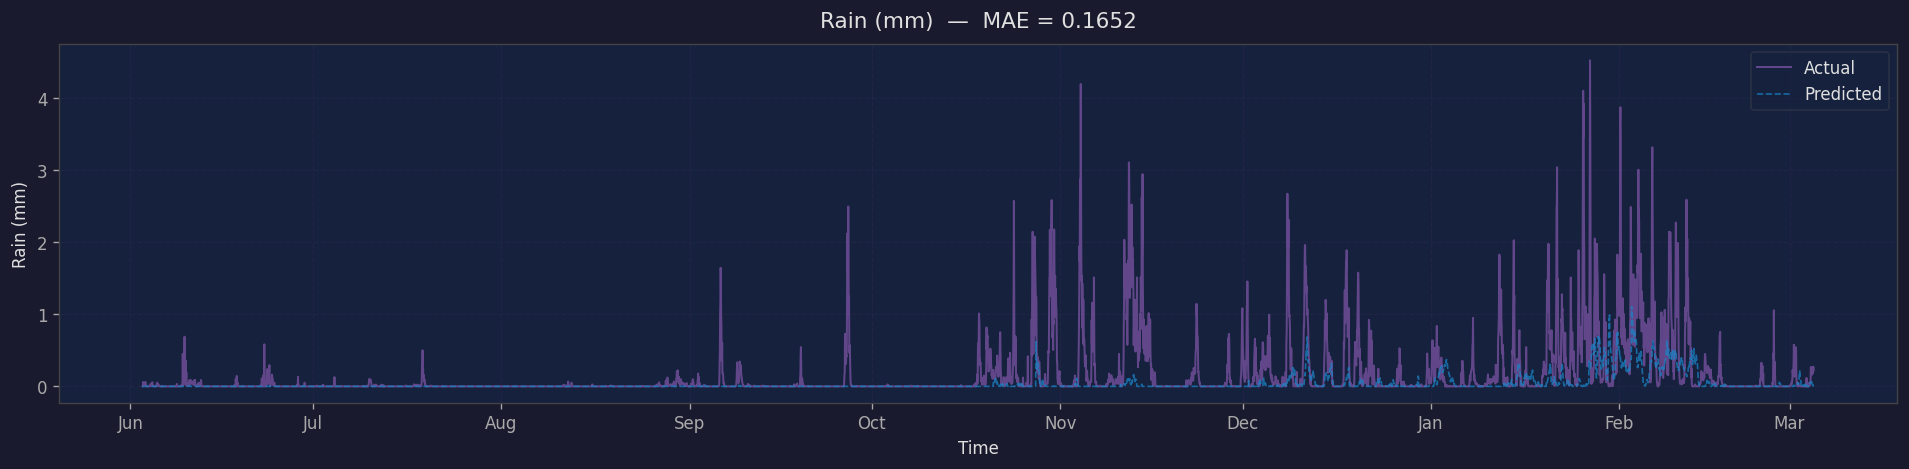

In [6]:
from pathlib import Path
from IPython.display import Image, display

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

img = _plots_dir() / 'target_rain_actual_vs_pred.png'
display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.4 MAE Evolution Across Walk-Forward Steps

This chart shows how the per-week MAE evolves as the training window expands across all 40 steps.

**Temperature (top panel, red):**
- MAE fluctuates between ~1.37 and ~2.99°C around the average of 2.024°C
- No clear downward trend — more training data does not automatically reduce error
- The variability reflects real seasonal difficulty: some weeks (winter cold snaps, summer heat waves) are inherently harder to forecast than others
- Steps 10 and 32 show spikes — likely weeks with anomalous weather events that deviate from learned patterns

**Rain (bottom panel, purple):**
- First ~18 steps show near-zero MAE — this corresponds to the dry summer months (June–September) when virtually no rain falls; correctly predicting zero is easy
- MAE spikes dramatically from step ~19 onward (November–January) when the Atlantic rain season begins
- The spike at step ~23 (~0.70 mm) and step ~35 (~0.80 mm) represent particularly intense rain weeks
- This seasonal pattern is important: **rain forecasting is hardest in winter**, when it matters most


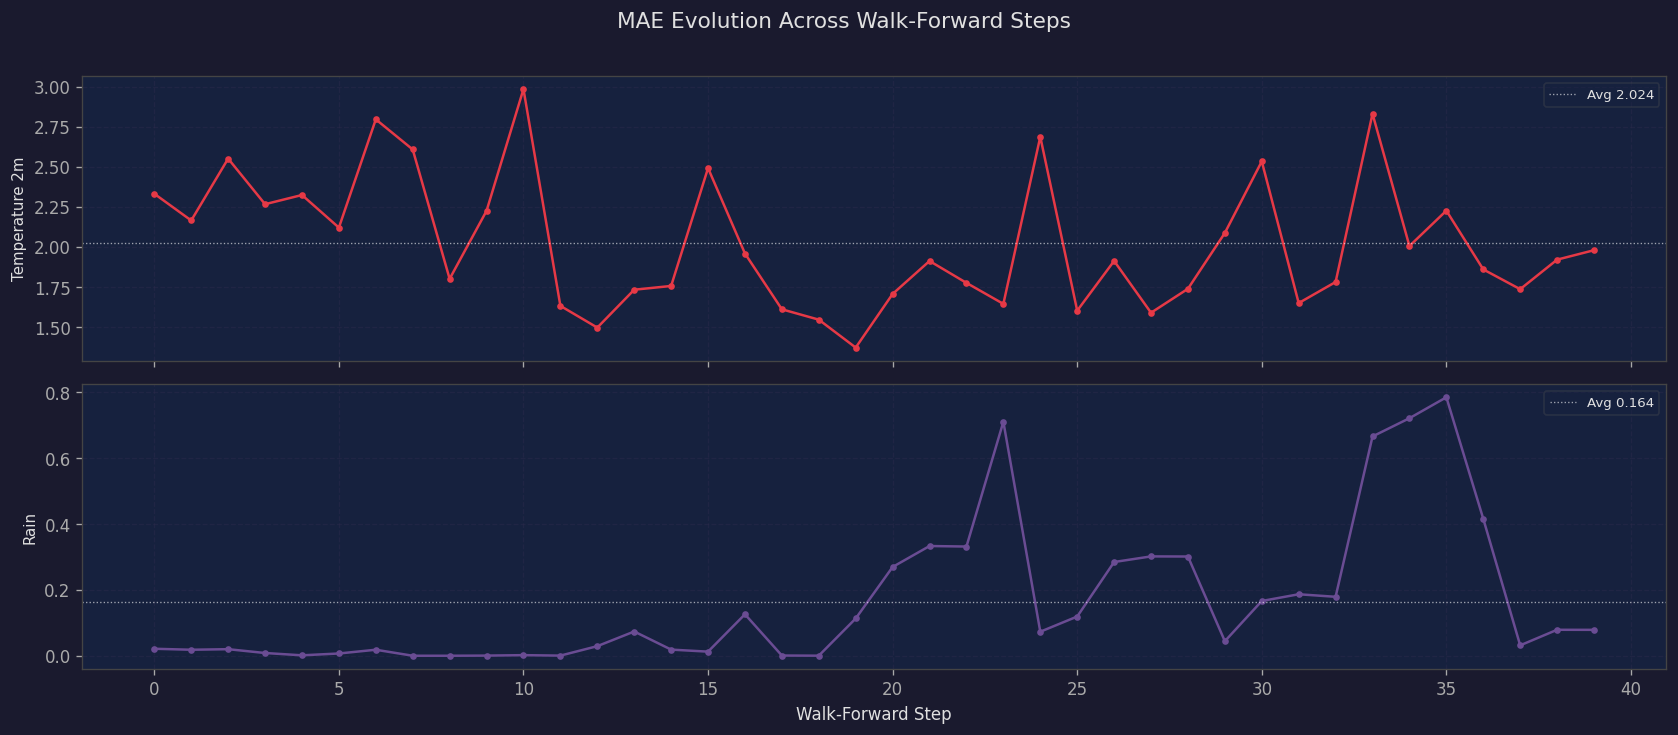

In [7]:
from pathlib import Path
from IPython.display import Image, display

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

img = _plots_dir() / 'mae_evolution.png'
display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.5 Rain Diagnostics

The evaluation report includes a dedicated diagnostics section for the rain target:

| Diagnostic | Value | Interpretation |
|---|---|---|
| Actual non-zero rate | 18.3% | Rain falls in about 1 in 5 hours |
| Predicted non-zero rate | 11.4% | Model predicts rain less often than it occurs — conservative |
| Pred mean when actual = 0 | 0.017 mm | Very low false-drizzle prediction — good dry-day behaviour |
| Pred mean when actual > 0 | 0.123 mm | Only 0.123 mm predicted vs actual rainy hours average — severe underestimation |
| Max actual rain | 22.8 mm | Extreme event |
| Max predicted rain | 3.2 mm | Model never predicts above 3.2 mm — unable to forecast heavy events |

The Tweedie model's **conservative nature** is both a strength (low false alarms) and a weakness (heavy events are severely underestimated). This is a known trade-off with Tweedie regression on sparse data.


---
## 8. Conclusions

### What Worked Well
- **LightGBM for temperature** achieved strong results (R²=0.879, Pearson r=0.938) — cyclical encoding and lag features gave the model enough context to capture diurnal and seasonal patterns
- **Tweedie XGBoost for rain** avoids the two-stage classifier trap and produces very low false-drizzle rates (mean 0.017 mm on dry hours)
- **Walk-forward validation** provides a realistic, leakage-free estimate of production performance
- **Model caching** makes inference near-instant after the first training run
- **Rain diagnostics** the model usally make the rain prediction ok but it is not able to predict heavy rain events, which are the most important to forecast accurately. This is a known limitation of Tweedie regression on sparse data.